# K-Means Clustering Analysis for Heart Disease Prediction
**Machine Learning Assignment — Member 4**  
**Algorithm: K-Means Clustering (Unsupervised Learning)**

---

## 1. Objective
Use K-Means clustering to segment Cleveland heart disease patients into risk groups.
This notebook loads the processed Cleveland dataset, creates patient clusters, and visualizes group structure.

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

ROOT_DIR = os.path.abspath('..')
sys.path.append(ROOT_DIR)

from src.data_preprocessing import load_data, preprocess_data

print('Imports loaded successfully')

Imports loaded successfully


In [2]:
DATA_PATH = os.path.join('..', 'Data_set', 'processed.cleveland.data')
raw_df = load_data(DATA_PATH)
print(f'Raw dataset shape: {raw_df.shape}')
print(raw_df.head())

clean_df = preprocess_data(raw_df)
print(f'Clean dataset shape: {clean_df.shape}')
print(clean_df.head())

Raw dataset shape: (303, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  
Clean dataset shape: (303, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0  

In [3]:
X = clean_df.drop(columns=['target']).astype(float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature scaling complete')
print('Shape after scaling:', X_scaled.shape)

Feature scaling complete
Shape after scaling: (303, 13)


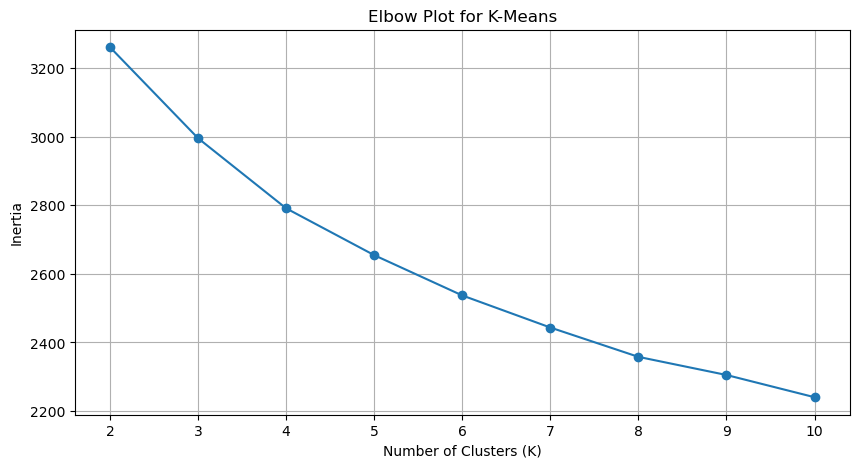

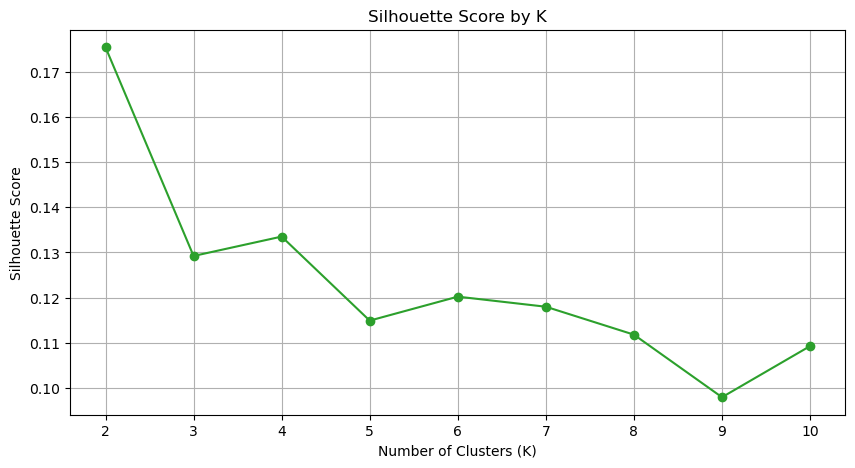

In [4]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(K_range), inertias, marker='o', color='tab:blue')
ax.set_title('Elbow Plot for K-Means')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(K_range), silhouette_scores, marker='o', color='tab:green')
ax.set_title('Silhouette Score by K')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.grid(True)
plt.show()

In [5]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

clean_df['Cluster'] = cluster_labels
clean_df['Risk_Group'] = clean_df['Cluster'].map({0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'})

print(clean_df['Risk_Group'].value_counts())
print(clean_df.groupby('Risk_Group').mean().loc[:, ['age', 'thalach', 'trestbps', 'chol']])

Risk_Group
Medium Risk    121
High Risk      107
Low Risk        75
Name: count, dtype: int64
                   age     thalach    trestbps        chol
Risk_Group                                                
High Risk    58.130841  131.355140  135.280374  251.598131
Low Risk     58.093333  151.253333  133.080000  268.933333
Medium Risk  48.909091  164.727273  127.652893  228.570248


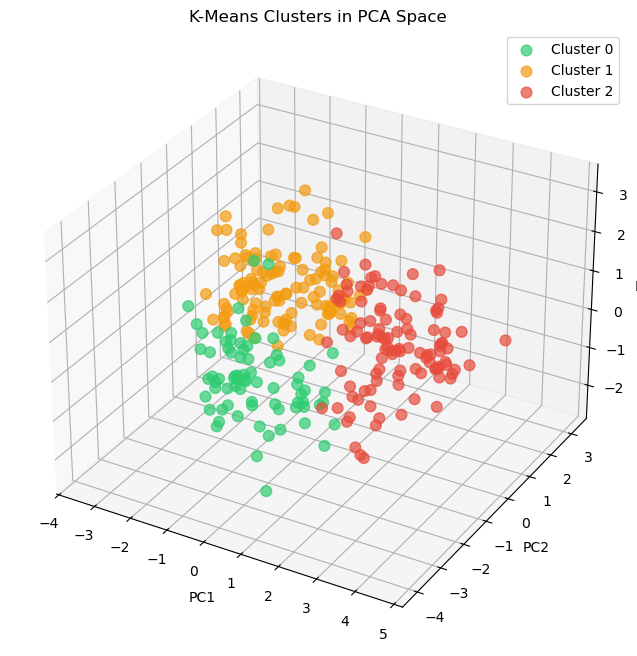

Explained variance ratio: [0.237 0.123 0.095]


In [6]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
colors = ['#2ecc71', '#f39c12', '#e74c3c']
for i in range(optimal_k):
    mask = cluster_labels == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2], color=colors[i], label=f'Cluster {i}', alpha=0.7, s=60)
ax.set_title('K-Means Clusters in PCA Space')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()
plt.show()
print('Explained variance ratio:', np.round(pca.explained_variance_ratio_, 3))

In [7]:
OUTPUT_DIR = os.path.join('..', 'outputs', 'kmeans')
os.makedirs(OUTPUT_DIR, exist_ok=True)
clean_df.to_csv(os.path.join(OUTPUT_DIR, 'notebook_clustered_patients.csv'), index=False)
print('Saved clustered patient assignments to', os.path.join(OUTPUT_DIR, 'notebook_clustered_patients.csv'))

Saved clustered patient assignments to ..\outputs\kmeans\notebook_clustered_patients.csv
